In [69]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [70]:
labels_map = {
    "hungry": "hungry",
    "discomfort": "discomfort",
    "tired": "tired",
    "scared": "scared"
}

label_names = ["hungry", "discomfort", "tired", "scared"]
label_to_index = {label: i for i, label in enumerate(label_names)}

In [71]:
def extract_spectrogram(file_path, augment=False):
    y, sr = librosa.load(file_path, sr=16000)

    # fix length (2 sec)
    max_len = 2 * sr
    if len(y) > max_len:
        y = y[:max_len]
    else:
        y = np.pad(y, (0, max_len - len(y)))

    # ✅ ONLY augment during training
    if augment:
        if np.random.rand() > 0.5:
            y = y + 0.003 * np.random.randn(len(y))  # noise

        if np.random.rand() > 0.5:
            shift = np.random.randint(len(y) // 10)
            y = np.roll(y, shift)  # shift

    # mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # fix NaN/inf
    mel_db = np.nan_to_num(mel_db)

    return mel_db


In [72]:
base = "dataset"

X = []
y = []

for folder in os.listdir(base):
    path = os.path.join(base, folder)

    for file in os.listdir(path):
        file_path = os.path.join(path, file)

        try:
            spec = extract_spectrogram(file_path)

            X.append(spec)
            y.append(label_to_index[labels_map[folder]])

        except:
            pass

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)


Shape: (714, 128, 63)


In [73]:
from sklearn.utils import resample

# Get class counts
unique_classes, class_counts = np.unique(y, return_counts=True)
max_count = max(class_counts)

# Balance all classes
X_balanced = []
y_balanced = []

for class_idx in unique_classes:
    X_class = X[y == class_idx]
    y_class = y[y == class_idx]
    
    # Upsample to match the majority class
    X_upsampled, y_upsampled = resample(
        X_class, y_class,
        replace=True,
        n_samples=max_count,
        random_state=42
    )
    
    X_balanced.append(X_upsampled)
    y_balanced.append(y_upsampled)

# Combine all balanced classes
X = np.concatenate(X_balanced)
y = np.concatenate(y_balanced)

In [74]:
# 🔥 FIX NaN / inf
X = np.nan_to_num(X)

# 🔥 SAFE normalization
X_min = np.min(X)
X_max = np.max(X)

X = (X - X_min) / (X_max - X_min + 1e-8)

# reshape for CNN
if X.ndim == 3:
    X = X[..., np.newaxis]

# one-hot labels
while y.ndim > 1:
    y = np.argmax(y, axis=-1)
y = to_categorical(y, num_classes=len(label_names))

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Before augmentation:", X_train.shape)

# Augment training data
def augment_spectrogram(spec):
    augmented = []
    for _ in range(2):  # create 2 augmented versions per original
        s = spec.copy()
        # Add noise
        if np.random.rand() > 0.5:
            noise = 0.01 * np.random.randn(*s.shape)
            s += noise
        # Time shift
        if np.random.rand() > 0.5:
            shift = np.random.randint(s.shape[1] // 10)
            s = np.roll(s, shift, axis=1)
        # Frequency masking
        if np.random.rand() > 0.5:
            mask_start = np.random.randint(0, s.shape[0] - 10)
            mask_width = np.random.randint(5, 15)
            s[mask_start:mask_start+mask_width, :] = 0
        # Time masking
        if np.random.rand() > 0.5:
            mask_start = np.random.randint(0, s.shape[1] - 5)
            mask_width = np.random.randint(2, 8)
            s[:, mask_start:mask_start+mask_width] = 0
        augmented.append(s)
    return augmented

# Augment X_train
X_train_aug = []
y_train_aug = []

for i in range(len(X_train)):
    X_train_aug.append(X_train[i])
    y_train_aug.append(y_train[i])
    
    # Add augmented versions
    aug_specs = augment_spectrogram(X_train[i][:, :, 0])  # remove channel dim for aug
    for aug_spec in aug_specs:
        aug_spec = aug_spec[..., np.newaxis]  # add channel back at end
        X_train_aug.append(aug_spec)
        y_train_aug.append(y_train[i])

X_train = np.array(X_train_aug)
y_train = np.array(y_train_aug)

print("Augmented training shape:", X_train.shape)


Before augmentation: (1270, 128, 63, 1)
Augmented training shape: (3810, 128, 63, 1)


In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert one-hot back to flat class labels for class weight computation
y_train_labels = np.asarray(y_train)
while y_train_labels.ndim > 1:
    y_train_labels = np.argmax(y_train_labels, axis=-1)
y_train_labels = y_train_labels.astype(int).ravel()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

# Improved model with more layers and regularization
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Class Weights: {0: np.float64(1.0275080906148868), 1: np.float64(1.0209003215434083), 2: np.float64(0.9679878048780488), 3: np.float64(0.9860248447204969)}


/home/future/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 61, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 61, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,108 (434.02 KB)

 Trainable params: 110,404 (431.27 KB)

 Non-trainable params: 704 (2.75 KB)

In [93]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)



Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.8244 - loss: 0.4260 - val_accuracy: 0.7107 - val_loss: 0.6984 - learning_rate: 6.2500e-05
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.8297 - loss: 0.4280 - val_accuracy: 0.7736 - val_loss: 0.6283 - learning_rate: 6.2500e-05
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.8323 - loss: 0.4284 - val_accuracy: 0.7138 - val_loss: 0.7030 - learning_rate: 6.2500e-05
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 28s 117ms/step - accuracy: 0.8399 - loss: 0.4030 - val_accuracy: 0.7453 - val_loss: 0.6705 - learning_rate: 6.2500e-05
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 28s 117ms/step - accuracy: 0.8386 - loss: 0.4087 - val_accuracy: 0.7170 - val_loss: 0.6772 - learning_rate: 6.2500e-05
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.8294 - loss: 0.4072 - val_accuracy: 0.7264 - val_loss: 0.7100 - learning_rate: 6.2500e-05
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 

In [95]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7736 - loss: 0.6283
Accuracy: 0.7735849022865295


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
              precision    recall  f1-score   support

      hungry       0.80      0.47      0.59        88
  discomfort       0.76      0.83      0.79        86
       tired       0.60      0.86      0.71        69
      scared       1.00      1.00      1.00        75

    accuracy                           0.77       318
   macro avg       0.79      0.79      0.77       318
weighted avg       0.79      0.77      0.77       318



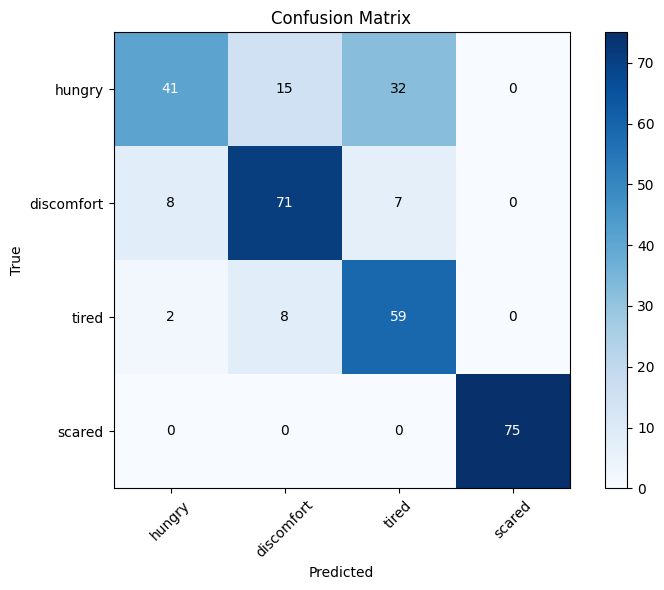

In [96]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(range(4), label_names, rotation=45)
plt.yticks(range(4), label_names)

# Add text annotations
for i in range(4):
    for j in range(4):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()


In [80]:
print(len(X_train))


3810


In [97]:
model.save("baby_cry_model.h5")


In [98]:
def predict_audio(file_path):
    spec = extract_spectrogram(file_path)

    spec = np.nan_to_num(spec)
    spec = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-8)

    spec = spec[..., np.newaxis]
    spec = np.expand_dims(spec, axis=0)

    prediction = model.predict(spec)
    return prediction


In [99]:
pred = predict_audio("dataset/scared/sc-4.wav")

predicted_class_idx = np.argmax(pred[0])
predicted_label = label_names[predicted_class_idx]

print(f"Predicted: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: scared


In [110]:
pred = predict_audio("dataset/hungry/hu-1.wav")
predicted_class_idx = np.argmax(pred[0])
predicted_label = label_names[predicted_class_idx]
print(f"Predicted: {predicted_label}")
print("Probabilities:", pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted: tired
Probabilities: [3.2434082e-01 2.7044022e-01 4.0511936e-01 9.9609693e-05]


In [111]:
pred = predict_audio("dataset/scared/sc-11.wav")
predicted_class_idx = np.argmax(pred[0])
predicted_label = label_names[predicted_class_idx]
print(f"Predicted: {predicted_label}")
print("Probabilities:", pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: scared
Probabilities: [2.8313170e-06 3.6308816e-06 2.3794981e-05 9.9996972e-01]


In [115]:
hungry_dir = "dataset/hungry"
hungry_files = [f for f in os.listdir(hungry_dir) if f.lower().endswith('.wav')]

correct = 0
for fname in hungry_files:
    path = os.path.join(hungry_dir, fname)
    pred = predict_audio(path)
    predicted_idx = np.argmax(pred[0])
    predicted_label = label_names[predicted_idx]
    is_correct = predicted_label == 'hungry'
    if is_correct:
        correct += 1
    print(f"{fname}: {predicted_label} (confidence={pred[0][predicted_idx]:.4f})")

if hungry_files:
    print(f"\nHungry folder correctness: {correct}/{len(hungry_files)} = {correct/len(hungry_files):.2%}")
else:
    print("No .wav files found in dataset/hungry")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1259bcad-2308-46fa-9a36-b5d8f359886a-1430143617162-1.7-m-04-hu.wav: hungry (confidence=0.9301)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
B327333E-2DE2-4833-A75A-4C576208BED3-1430087429-1.0-f-48-hu.wav: tired (confidence=0.7680)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
a40b9b8d-e4bc-457a-badf-f38bdbc0c358-1430016779981-1.7-m-26-hu.wav: hungry (confidence=0.6775)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
090C15A8-5406-4EA5-97A3-81F6527227C0-1430147515-1.0-m-72-hu.wav: hungry (confidence=0.8242)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
92d08bbe-553f-4844-85b1-15d572f06ea2-1436873183951-1.7-m-04-hu.wav: tired (confidence=0.9116)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
653bf718-94bd-40d0-af7c-8fe44e07640c-1430759231913-1.7-m-04-hu.wav: hungry (confidence=0.6700)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
c42e76b9-a4c1-48f6-a91d-27ab83015874-1430737177322-1.7-f-72-hu.wav: hungry (confidence=0.7488)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
30c2cee4-b682-4dcb-86b9-7fa6f36f1b66-14

In [90]:
from sklearn.metrics import classification_report, confusion_matrix

y_preds = []
y_trues = []

for fname in hungry_files:
    path = os.path.join(hungry_dir, fname)
    pred = predict_audio(path)
    y_preds.append(np.argmax(pred[0]))
    y_trues.append(label_to_index['hungry'])

print(classification_report(y_trues, y_preds, target_names=label_names))
print(confusion_matrix(y_trues, y_preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━

/home/future/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/future/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/future/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
